In [119]:
import osmnx as ox

import pandas as pd
import numpy as np

from pathlib import Path

import requests
import json

from rapidfuzz import fuzz
from unidecode import unidecode

from sklearn.preprocessing import OneHotEncoder

import matplotlib.pyplot as plt
import seaborn as sns

import yaml

# Load HCM data

In [120]:
RAW_PATH = Path("../data/raw")

In [121]:
nodes_df = pd.read_csv(RAW_PATH/"nodes.csv")
segments_df = pd.read_csv(RAW_PATH/"segments.csv")
status_df = pd.read_csv(RAW_PATH/"segment_status.csv")
streets_df = pd.read_csv(RAW_PATH/"streets.csv")
train_df = pd.read_csv(RAW_PATH/"train.csv")

In [122]:
status_df["updated_at"] = (
    pd.to_datetime(status_df["updated_at"], utc=True)
    .dt.tz_localize(None)
)

In [123]:
train_df

,_id,segment_id,date,weekday,period,LOS,s_node_id,e_node_id,length,street_id,max_velocity,street_level,street_name,street_type,long_snode,lat_snode,long_enode,lat_enode
0,0,26,2021-04-16,4,period_0_30,A,366428456,366416066,116,32575820,NaN,4,Nguyễn Văn Bá,tertiary,106.768732,10.841506,106.769254,10.842422
1,1,33,2020-08-02,6,period_23_30,C,366469460,3792257828,26,32575862,NaN,3,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808
2,2,33,2020-08-03,0,period_0_00,D,366469460,3792257828,26,32575862,NaN,3,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808
3,3,67,2021-03-09,1,period_9_30,B,366403668,5755066033,7,32575862,NaN,3,Đường số 5,secondary,106.768412,10.880817,106.768461,10.880771
4,4,67,2021-03-23,1,period_9_30,B,366403668,5755066033,7,32575862,NaN,3,Đường số 5,secondary,106.768412,10.880817,106.768461,10.880771
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33436,33436,84529,2021-01-05,1,period_8_00,F,411918572,1226517262,13,654864528,NaN,2,Nguyễn Thị Minh Khai,primary,106.704503,10.789614,106.704584,10.789702
33437,33437,84533,2021-01-09,5,period_13_30,F,4597281310,411918528,126,654864530,NaN,4,Nguyễn Bỉnh Khiêm,tertiary,106.704986,10.787267,106.704149,10.788051
33438,33438,84533,2021-04-22,3,period_5_00,F,4597281310,411918528,126,654864530,NaN,4,Nguyễn Bỉnh Khiêm,tertiary,106.704986,10.787267,106.704149,10.788051
33439,33439,84534,2021-01-09,5,period_13_30,D,411918528,411925985,89,654864530,NaN,4,Nguyễn Bỉnh Khiêm,tertiary,106.704149,10.788051,106.703549,10.788604


In [124]:
# Quy date + period của train về cùng mốc thời gian 30 phút với status.
time_parts = train_df["period"].str.extract(
    r"^period_(\d{1,2})_(\d{2})$",
    expand=True,
).astype(int)

train_df["timestamp"] = (
    pd.to_datetime(train_df["date"])
    + pd.to_timedelta(time_parts[0], unit="h")
    + pd.to_timedelta(time_parts[1], unit="m")
)
status_df["timestamp"] = status_df["updated_at"].dt.floor("30min")

In [125]:
# Một segment có thể có nhiều status trong cùng 30 phút; lấy velocity trung bình
# để mỗi khóa (segment_id, timestamp) chỉ còn một dòng.
status_30m_df = (
    status_df.groupby(["segment_id", "timestamp"], as_index=False)
    .agg(
        velocity=("velocity", "mean"),
        status_count=("velocity", "size"),
    )
)

In [126]:
merged_df = train_df.merge(
    status_30m_df,
    how="left",
    on=["segment_id", "timestamp"],
    validate="one_to_one",
)

print(f"Số dòng sau merge: {len(merged_df):,}")
print(f"Số dòng không khớp status: {merged_df['velocity'].isna().sum():,}")
merged_df.head()

Số dòng sau merge: 33,441
Số dòng không khớp status: 0


,_id,segment_id,date,weekday,period,LOS,s_node_id,e_node_id,length,street_id,...,street_level,street_name,street_type,long_snode,lat_snode,long_enode,lat_enode,timestamp,velocity,status_count
0,0,26,2021-04-16,4,period_0_30,A,366428456,366416066,116,32575820,...,4,Nguyễn Văn Bá,tertiary,106.768732,10.841506,106.769254,10.842422,2021-04-16 00:30:00,117.0,1
1,1,33,2020-08-02,6,period_23_30,C,366469460,3792257828,26,32575862,...,3,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808,2020-08-02 23:30:00,30.0,2
2,2,33,2020-08-03,0,period_0_00,D,366469460,3792257828,26,32575862,...,3,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808,2020-08-03 00:00:00,20.0,8
3,3,67,2021-03-09,1,period_9_30,B,366403668,5755066033,7,32575862,...,3,Đường số 5,secondary,106.768412,10.880817,106.768461,10.880771,2021-03-09 09:30:00,33.0,1
4,4,67,2021-03-23,1,period_9_30,B,366403668,5755066033,7,32575862,...,3,Đường số 5,secondary,106.768412,10.880817,106.768461,10.880771,2021-03-23 09:30:00,32.0,1


In [127]:
merged_df.head()

,_id,segment_id,date,weekday,period,LOS,s_node_id,e_node_id,length,street_id,...,street_level,street_name,street_type,long_snode,lat_snode,long_enode,lat_enode,timestamp,velocity,status_count
0,0,26,2021-04-16,4,period_0_30,A,366428456,366416066,116,32575820,...,4,Nguyễn Văn Bá,tertiary,106.768732,10.841506,106.769254,10.842422,2021-04-16 00:30:00,117.0,1
1,1,33,2020-08-02,6,period_23_30,C,366469460,3792257828,26,32575862,...,3,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808,2020-08-02 23:30:00,30.0,2
2,2,33,2020-08-03,0,period_0_00,D,366469460,3792257828,26,32575862,...,3,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808,2020-08-03 00:00:00,20.0,8
3,3,67,2021-03-09,1,period_9_30,B,366403668,5755066033,7,32575862,...,3,Đường số 5,secondary,106.768412,10.880817,106.768461,10.880771,2021-03-09 09:30:00,33.0,1
4,4,67,2021-03-23,1,period_9_30,B,366403668,5755066033,7,32575862,...,3,Đường số 5,secondary,106.768412,10.880817,106.768461,10.880771,2021-03-23 09:30:00,32.0,1


In [128]:
merged_df["velocity"] = merged_df["velocity"].fillna(40)

C:\Users\Asriel\AppData\Local\Temp\ipykernel_22888\2002002932.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(merged_df["velocity"], labels=["velocity"])


Text(0.5, 1.0, 'Biểu đồ boxplot thể hiện sự phân bố của velocity trong các bản ghi')

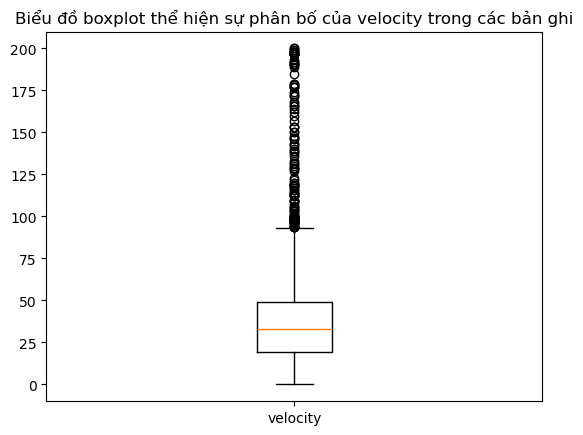

In [129]:
plt.boxplot(merged_df["velocity"], labels=["velocity"])
plt.title("Biểu đồ boxplot thể hiện sự phân bố của velocity trong các bản ghi")

In [130]:
merged_df["velocity"].max()

np.float64(200.0)

In [131]:
merged_df["velocity"].min()

np.float64(0.0)

In [132]:
merged_df["velocity"].mean()

np.float64(33.48063119268923)

In [133]:
np.quantile(merged_df["velocity"], 0.25)

np.float64(19.375)

In [134]:
np.quantile(merged_df["velocity"], 0.75)

np.float64(49.0)

In [135]:
status_df.head()

,_id,updated_at,segment_id,velocity,timestamp
0,0,2020-07-03 14:55:31.869,24845,20,2020-07-03 14:30:00
1,1,2020-07-03 15:02:56.048,33923,10,2020-07-03 15:00:00
2,2,2020-07-04 08:15:52.696,33824,5,2020-07-04 08:00:00
3,3,2020-07-04 08:15:59.903,33824,5,2020-07-04 08:00:00
4,4,2020-07-04 08:16:08.201,33824,5,2020-07-04 08:00:00


In [136]:
train_df.head()

,_id,segment_id,date,weekday,period,LOS,s_node_id,e_node_id,length,street_id,max_velocity,street_level,street_name,street_type,long_snode,lat_snode,long_enode,lat_enode,timestamp
0,0,26,2021-04-16,4,period_0_30,A,366428456,366416066,116,32575820,NaN,4,Nguyễn Văn Bá,tertiary,106.768732,10.841506,106.769254,10.842422,2021-04-16 00:30:00
1,1,33,2020-08-02,6,period_23_30,C,366469460,3792257828,26,32575862,NaN,3,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808,2020-08-02 23:30:00
2,2,33,2020-08-03,0,period_0_00,D,366469460,3792257828,26,32575862,NaN,3,Đường số 5,secondary,106.761957,10.878650,106.762143,10.878808,2020-08-03 00:00:00
3,3,67,2021-03-09,1,period_9_30,B,366403668,5755066033,7,32575862,NaN,3,Đường số 5,secondary,106.768412,10.880817,106.768461,10.880771,2021-03-09 09:30:00
4,4,67,2021-03-23,1,period_9_30,B,366403668,5755066033,7,32575862,NaN,3,Đường số 5,secondary,106.768412,10.880817,106.768461,10.880771,2021-03-23 09:30:00


In [137]:
merged_df["velocity"].min() - 1.5*np.quantile(merged_df["velocity"],0.25)

np.float64(-29.0625)

In [138]:
merged_df["velocity"].describe()

count    33441.000000
mean        33.480631
std         19.197111
min          0.000000
25%         19.375000
50%         33.000000
75%         49.000000
max        200.000000
Name: velocity, dtype: float64

In [139]:
train_df.shape

(33441, 19)

In [140]:
status_30m_df.shape

(33441, 4)

In [141]:
merged_df[merged_df["velocity"] > 120]

,_id,segment_id,date,weekday,period,LOS,s_node_id,e_node_id,length,street_id,...,street_level,street_name,street_type,long_snode,lat_snode,long_enode,lat_enode,timestamp,velocity,status_count
111,111,985,2020-12-18,4,period_1_30,A,3191421708,1497312726,40,32576602,...,3,Trần Não,secondary,106.730462,10.791228,106.730523,10.791589,2020-12-18 01:30:00,127.0,1
3740,3740,10083,2020-11-30,0,period_11_30,A,5753172781,2340079035,159,32582981,...,4,Vườn Lài,tertiary,106.694742,10.841328,106.695431,10.840061,2020-11-30 11:30:00,142.0,1
3741,3741,10085,2020-11-29,6,period_15_00,A,5753152931,5753172781,52,32582981,...,4,Vườn Lài,tertiary,106.694532,10.841755,106.694742,10.841328,2020-11-29 15:00:00,166.0,1
3784,3784,10317,2020-12-09,2,period_15_00,A,2332788978,5758041267,16,32583282,...,4,Võ Văn Ngân,tertiary,106.755031,10.851171,106.755182,10.851181,2020-12-09 15:00:00,189.0,1
3801,3801,10501,2020-12-09,2,period_15_00,A,2078950680,366377084,17,32583384,...,4,Nguyễn Thái Bình,tertiary,106.652379,10.796469,106.652478,10.796588,2020-12-09 15:00:00,172.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31379,31379,75460,2020-11-21,5,period_10_30,A,5726962500,2340081998,18,605511911,...,4,Đường đất,tertiary,106.693106,10.830731,106.692969,10.830835,2020-11-21 10:30:00,139.0,1
31837,31837,78272,2021-01-05,1,period_4_30,A,4766262068,2938679167,42,606923269,...,4,Nguyễn Du,tertiary,106.786924,10.879975,106.786536,10.880027,2021-01-05 04:30:00,191.0,1
32184,32184,79772,2020-11-29,6,period_12_30,A,4937800746,5762755216,7,608194035,...,4,Dường An Phú,unclassified,106.684492,10.847845,106.684558,10.847845,2020-11-29 12:30:00,179.0,1
32186,32186,79820,2020-12-16,2,period_6_00,A,4937800754,4937800755,70,608194041,...,4,Dường An Phú,unclassified,106.689610,10.844145,106.689748,10.843523,2020-12-16 06:00:00,177.0,1


## Kết hợp thuộc tính `tags.oneway` từ OSM

Ghép OSM way với dữ liệu train theo `street_id`. Quy ước: `yes` là một chiều theo thứ tự node của OSM, `-1` là một chiều ngược thứ tự node, còn `no` là hai chiều hoặc không có thông tin hợp lệ.

In [142]:
OSM_PATH = RAW_PATH / "osm_train_2019_01_03.json"

with OSM_PATH.open("r", encoding="utf-8") as osm_file:
    osm_data = json.load(osm_file)

osm_ways_df = pd.json_normalize(
    element for element in osm_data["elements"] if element.get("type") == "way"
)

osm_tag_columns = ["tags.oneway", "tags.motorroad"]
for column in osm_tag_columns:
    if column not in osm_ways_df.columns:
        osm_ways_df[column] = pd.NA

osm_way_tags_df = osm_ways_df[["id"] + osm_tag_columns].rename(
    columns={"id": "street_id"}
)
if osm_way_tags_df["street_id"].duplicated().any():
    raise ValueError("OSM chứa nhiều way trùng id; không thể merge many-to-one")

valid_oneway_values = {"yes", "no", "-1"}
osm_way_tags_df["tags.oneway"] = (
    osm_way_tags_df["tags.oneway"]
    .astype("string")
    .str.strip()
    .str.lower()
    .where(lambda values: values.isin(valid_oneway_values), "no")
    .fillna("no")
)

valid_motorroad_values = {"yes", "no"}
osm_way_tags_df["tags.motorroad"] = (
    osm_way_tags_df["tags.motorroad"]
    .astype("string")
    .str.strip()
    .str.lower()
    .where(lambda values: values.isin(valid_motorroad_values), "no")
    .fillna("no")
)

merged_df = merged_df.drop(columns=osm_tag_columns, errors="ignore").merge(
    osm_way_tags_df,
    how="left",
    on="street_id",
    validate="many_to_one",
)
merged_df["tags.oneway"] = merged_df["tags.oneway"].fillna("no")
merged_df["tags.motorroad"] = merged_df["tags.motorroad"].fillna("no")

print(f"Số dòng sau khi ghép thuộc tính OSM: {len(merged_df):,}")
print(merged_df["tags.oneway"].value_counts(dropna=False))
print(merged_df["tags.motorroad"].value_counts(dropna=False))
merged_df[["segment_id", "street_id", "tags.oneway", "tags.motorroad"]].head()

Số dòng sau khi ghép thuộc tính OSM: 33,441
tags.oneway
yes    18341
no     15085
-1        15
Name: count, dtype: Int64
tags.motorroad
no     32808
yes      633
Name: count, dtype: Int64


,segment_id,street_id,tags.oneway,tags.motorroad
0,26,32575820,no,no
1,33,32575862,no,no
2,33,32575862,no,no
3,67,32575862,no,no
4,67,32575862,no,no


In [143]:
merged_df.columns

Index(['_id', 'segment_id', 'date', 'weekday', 'period', 'LOS', 's_node_id',
       'e_node_id', 'length', 'street_id', 'max_velocity', 'street_level',
       'street_name', 'street_type', 'long_snode', 'lat_snode', 'long_enode',
       'lat_enode', 'timestamp', 'velocity', 'status_count', 'tags.oneway',
       'tags.motorroad'],
      dtype='object')

In [144]:
merged_df["street_type"].unique()

array(['tertiary', 'secondary', 'unclassified', 'primary_link', 'primary',
       'trunk', 'trunk_link', 'residential', 'secondary_link',
       'tertiary_link', 'motorway_link', 'pitch', 'motorway',
       'convenience', 'university', 'car', 'house', 'company', 'school',
       'marketplace', 'fuel', 'clothes', 'government', 'bus_station',
       'bank', 'cinema'], dtype=object)

In [145]:
merged_df["tags.oneway"] = (
    merged_df["tags.oneway"]
    .fillna("no")
    .where(merged_df["tags.oneway"].isin(["yes", "no", "-1"]), "no")
)

In [156]:
merged_df[
    (merged_df["velocity"] >= 60) &
    (merged_df["tags.motorroad"] == "no") &
    (merged_df["tags.oneway"] == "yes") &
    (merged_df["street_type"] != "motorway")
]

,_id,segment_id,date,weekday,period,LOS,s_node_id,e_node_id,length,street_id,...,street_type,long_snode,lat_snode,long_enode,lat_enode,timestamp,velocity,status_count,tags.oneway,tags.motorroad
111,111,985,2020-12-18,4,period_1_30,A,3191421708,1497312726,40,32576602,...,secondary,106.730462,10.791228,106.730523,10.791589,2020-12-18 01:30:00,127.0,1,yes,no
112,112,996,2021-04-16,4,period_11_00,A,1497312738,1497312743,42,32576602,...,secondary,106.731147,10.795439,106.731212,10.795816,2021-04-16 11:00:00,96.0,1,yes,no
131,131,1549,2021-04-15,3,period_1_30,A,366443905,5735452021,5,32577095,...,tertiary,106.730620,10.800674,106.730571,10.800671,2021-04-15 01:30:00,60.0,1,yes,no
1094,1094,3075,2020-12-26,5,period_9_30,A,5213699015,1408031702,5,32577828,...,primary,106.678764,10.804675,106.678753,10.804725,2020-12-26 09:30:00,80.0,1,yes,no
1172,1172,3098,2020-11-29,6,period_13_00,C,5939097361,3129476042,15,32577919,...,primary,106.677940,10.845775,106.677895,10.845648,2020-11-29 13:00:00,82.0,2,yes,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33289,33289,84448,2020-12-28,0,period_6_30,A,3162508873,411926698,101,654858165,...,primary,106.687481,10.783390,106.686834,10.782732,2020-12-28 06:30:00,73.0,2,yes,no
33290,33290,84448,2020-12-28,0,period_7_00,A,3162508873,411926698,101,654858165,...,primary,106.687481,10.783390,106.686834,10.782732,2020-12-28 07:00:00,72.0,2,yes,no
33291,33291,84448,2020-12-28,0,period_7_30,A,3162508873,411926698,101,654858165,...,primary,106.687481,10.783390,106.686834,10.782732,2020-12-28 07:30:00,71.0,1,yes,no
33293,33293,84449,2020-12-09,2,period_15_00,A,411926698,5350682983,26,654858165,...,primary,106.686834,10.782732,106.686672,10.782548,2020-12-09 15:00:00,68.0,1,yes,no


In [157]:
merged_df[
    (merged_df["velocity"] >= 50) &
    (merged_df["tags.motorroad"] == "no") &
    (merged_df["tags.oneway"] == "no") &
    (merged_df["street_type"] != "motorway")
]

,_id,segment_id,date,weekday,period,LOS,s_node_id,e_node_id,length,street_id,...,street_type,long_snode,lat_snode,long_enode,lat_enode,timestamp,velocity,status_count,tags.oneway,tags.motorroad
0,0,26,2021-04-16,4,period_0_30,A,366428456,366416066,116,32575820,...,tertiary,106.768732,10.841506,106.769254,10.842422,2021-04-16 00:30:00,117.0,1,no,no
10,10,173,2020-12-28,0,period_4_30,A,2299416638,4639027499,9,32575943,...,tertiary,106.651613,10.786231,106.651699,10.786252,2020-12-28 04:30:00,68.0,1,no,no
11,11,173,2020-12-28,0,period_7_30,A,2299416638,4639027499,9,32575943,...,tertiary,106.651613,10.786231,106.651699,10.786252,2020-12-28 07:30:00,69.0,1,no,no
12,12,175,2020-12-09,2,period_14_00,A,4639027499,4639027501,67,32575943,...,tertiary,106.651699,10.786252,106.652296,10.786413,2020-12-09 14:00:00,67.0,1,no,no
13,13,175,2020-12-27,6,period_3_00,A,4639027499,4639027501,67,32575943,...,tertiary,106.651699,10.786252,106.652296,10.786413,2020-12-27 03:00:00,70.0,1,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33364,33364,84492,2020-12-28,0,period_5_00,A,2233449865,411923808,82,654861067,...,secondary,106.683044,10.784944,106.683741,10.784647,2020-12-28 05:00:00,79.0,1,no,no
33365,33365,84492,2020-12-28,0,period_5_30,A,2233449865,411923808,82,654861067,...,secondary,106.683044,10.784944,106.683741,10.784647,2020-12-28 05:30:00,79.0,2,no,no
33366,33366,84492,2020-12-28,0,period_6_00,A,2233449865,411923808,82,654861067,...,secondary,106.683044,10.784944,106.683741,10.784647,2020-12-28 06:00:00,79.0,1,no,no
33367,33367,84492,2020-12-28,0,period_6_30,A,2233449865,411923808,82,654861067,...,secondary,106.683044,10.784944,106.683741,10.784647,2020-12-28 06:30:00,79.0,2,no,no


In [155]:
merged_df[
    (merged_df["velocity"] >= 50) &
    (merged_df["tags.motorroad"] == "no") &
    (merged_df["tags.oneway"] == "yes") &
    (merged_df["street_type"] != "motorway")
]["street_name"].unique()

array(['Nguyễn Văn Lượng', 'Trần Não', 'Trần Đại Nghĩa',
       'Phường Linh Xuân', 'Nguyễn Kiệm', 'Nguyễn Oanh', 'Dương Bá Trạc',
       'Phan Đình Giót', 'Cầu Sài Gòn 1', 'Lê Văn Qưới', 'Quang Trung',
       'Nguyễn Hữu Trí', 'Phan Đăng Lưu', 'Bạch Đằng', 'Bùi Hữu Nghĩa',
       'Cầu vượt Nguyễn Hữu Cảnh', 'Hoàng Sa', 'Điện Biên Phủ',
       'Nguyễn Văn Trỗi', 'Cầu Thị Nghè', 'Pasteur', 'Cầu Công Lý',
       'Võ Văn Tần', 'Lê Văn Sỹ', 'Công Trường Dân Chủ',
       'Kinh Dương Vương', 'Cầu vượt Thủ Đức', 'Đinh Bộ Lĩnh',
       'Hoàng Minh Giám', 'Nguyễn Ðình Chiểu', 'Trần Khắc Chân',
       'Trần Huy Liệu', 'Cầu Phú Mỹ', 'Quốc lộ 1',
       'Vòng xoay Lạc Long Quân', 'Nguyễn Văn Linh', 'Cầu Tư Dinh',
       'Hoàng Văn Thụ', 'Phan Văn Trị', 'Trường Chinh',
       'Cầu vượt Sóng Thần 1', 'Mai Chí Thọ', 'Xa Lộ Hà Nội',
       'Quốc lộ 1A', 'Cầu vượt Trạm 2', 'Nguyễn Du', 'Tôn Thất Thuyết',
       'Phạm Hùng', 'Võ Văn Ngân', 'Nam Kỳ Khởi Nghĩa', 'Võ Thị Sáu',
       'Cộng Hòa', 'Cầu vượt 